In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------- USER INPUT --------
emory_file = "/hpc/home/yy450/link_dctrl_yy450/Sepy2.0/mimic_groupings/mimic_mapping_labs.csv"
# ----------------------------

# Load DataFrames
df_emory = pd.read_csv(emory_file)

print(f"✅ Loaded Emory: {df_emory.shape}")
print(f"📋 Emory Columns: {list(df_emory.columns)}")

# 🧪 Filter Emory by import
if "import" not in df_emory.columns:
    raise ValueError("'import' column not found in Emory file.")

✅ Loaded Emory: (62, 3)
📋 Emory Columns: ['import', 'super_table_col_name', 'component']


In [51]:

# Emory analysis: list of import values to filter by
emory_import = ['Yes']  
emory_col = "component"

In [52]:


df_emory_filtered = df_emory[df_emory["import"].isin(emory_import)]
print(f"🔍 Emory rows after filtering by import {emory_import}: {df_emory_filtered.shape[0]} rows")

# Check column existence
if emory_col not in df_emory_filtered.columns:
    raise ValueError(f"'{emory_col}' not found in Emory file (after filtering).")
# Extract target columns
e_col = df_emory_filtered[emory_col]
# e_col = df_emory[emory_col]

🔍 Emory rows after filtering by import ['Yes']: 62 rows


In [53]:

# -- 1. Null Count --
print("\n🧼 Null Counts:")
print(f"Emory - {emory_col}: {e_col.isnull().sum()} nulls out of {len(e_col)}")


🧼 Null Counts:
Emory - component: 0 nulls out of 62


In [54]:

# -- 2. Summary Stats --
print("\n📊 Summary Statistics:")
print("\nEmory:")
display(e_col.describe(include='all'))



📊 Summary Statistics:

Emory:


count            62
unique           62
top       Anion Gap
freq              1
Name: component, dtype: object

/tmp/ipykernel_1072591/687717455.py:19: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/hpc/dctrl/yy450/miniconda3/envs/sepy2/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128683 (\N{NO ENTRY SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


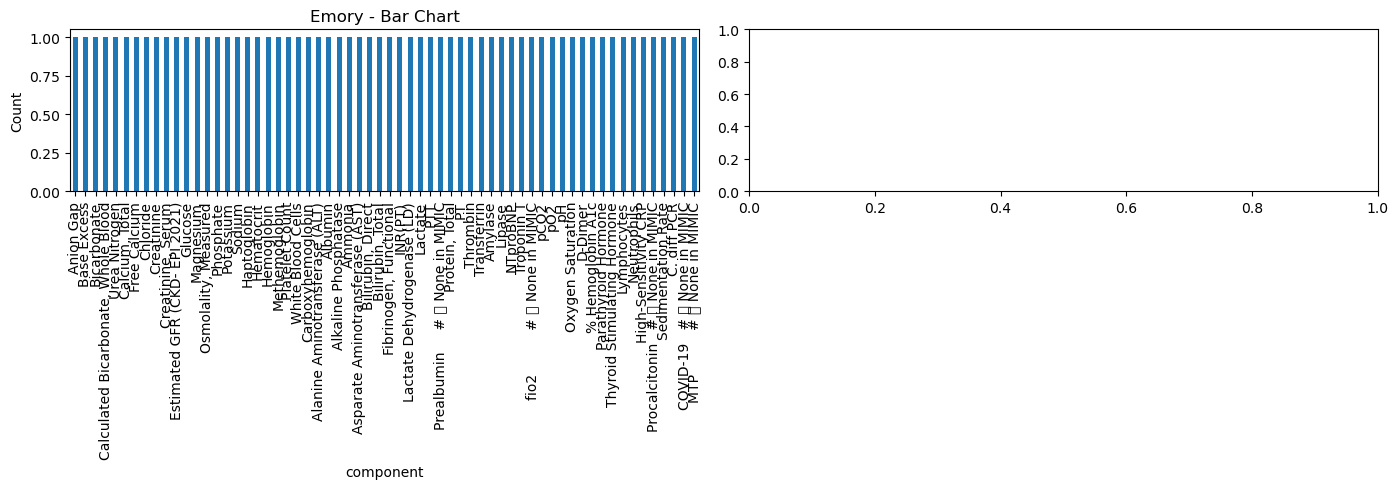

In [55]:
def plot_column_dist(col, source_name, ax, value_range=None):
    if pd.api.types.is_numeric_dtype(col):
        col_to_plot = col.dropna()
        if value_range:
            col_to_plot = col_to_plot[(col_to_plot >= value_range[0]) & (col_to_plot <= value_range[1])]
        sns.histplot(col_to_plot, kde=True, bins=50, ax=ax)
        ax.set_title(f"{source_name} - Histogram")
        ax.set_xlabel(col.name)
    else:
        col.value_counts().plot(kind='bar', ax=ax)
        ax.set_title(f"{source_name} - Bar Chart")
        ax.set_ylabel("Count")
        ax.set_xlabel(col.name)

value_range = (0, 5)  # <- 你可以修改这个范围

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_column_dist(e_col, "Emory", axes[0], value_range=value_range)
plt.tight_layout()
plt.show()


In [56]:
pd.set_option('display.max_rows', None)   # 显示所有行
# -- 3.5 Unique Values (for non-numeric) --
if not pd.api.types.is_numeric_dtype(e_col):
    print(f"\n📋 Emory unique values in '{emory_col}':")
    print(e_col.value_counts(dropna=False))


📋 Emory unique values in 'component':
component
Anion Gap                              1
Base Excess                            1
Bicarbonate                            1
Calculated Bicarbonate, Whole Blood    1
Urea Nitrogen                          1
Calcium, Total                         1
Free Calcium                           1
Chloride                               1
Creatinine                             1
Creatinine, Serum                      1
Estimated GFR (CKD- EPI 2021)          1
Glucose                                1
Magnesium                              1
Osmolality, Measured                   1
Phosphate                              1
Potassium                              1
Sodium                                 1
Haptoglobin                            1
Hematocrit                             1
Hemoglobin                             1
Methemoglobin                          1
Platelet Count                         1
White Blood Cells                      1
Carboxyh

In [77]:
if pd.api.types.is_numeric_dtype(e_col) and pd.api.types.is_numeric_dtype(m_col):
    plt.figure(figsize=(10, 5))

    e_kde = e_col.dropna()
    m_kde = m_col.dropna()

    if value_range:
        e_kde = e_kde[(e_kde >= value_range[0]) & (e_kde <= value_range[1])]
        m_kde = m_kde[(m_kde >= value_range[0]) & (m_kde <= value_range[1])]

    sns.kdeplot(e_kde, label='Emory', fill=True)
    sns.kdeplot(m_kde, label='MIMIC', fill=True)
    plt.title(f"Emory ({emory_col}) vs MIMIC ({mimic_col}) - KDE Overlay")
    plt.xlabel("Value")
    plt.legend()
    plt.show()
else:
    print("\n⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.")



⚠️ Skipping side-by-side KDE plot: one or both columns are not numeric.
